# Look-Ahead Standardization — how *one line of preprocessing* fakes a great backtest 🔮
### Why `z = (x - x.mean()) / x.std()` over the whole sample quietly cheats — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Full-sample standardisation leaks?: Confirmed](https://img.shields.io/badge/Full--sample_standardisation_leaks%3F-Confirmed-8b949e?style=flat-square)

Before you feed a feature to a model, you almost always **standardise** it — subtract its average, divide by how much it wobbles, so everything is on a comparable scale. Totally routine. But *when* you compute that average and wobble matters enormously. Do it over the **whole history at once** — the usual `(x - x.mean()) / x.std()` — and you have just used **future** data to rescale the past. Your backtest now knows things it couldn't have known.

We show what that does on a world we **built to contain no edge at all**: a purely random, unpredictable feature. The right way to standardise (using only the past) correctly finds *nothing*. The full-sample way conjures a strategy with a **Sharpe of 16** out of thin air.

> 📓 **This is the plain-language layer.** Want the Information Coefficient, the Newey-West *t*, and the random-walk maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on deterministic synthetic worlds. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lookahead_standardization import data, strategy as st

# Everything runs on deterministic, offline seed-837 synthetic worlds. Synthetic-only method demo:
# there is no real-tape cell by design (real free data can never certify "zero edge").
Xns, Rns = data.null_nonstationary(seed=data.BASE_SEED)   # the trap (random-walk feature)
Xst, Rst = data.null_stationary(seed=data.BASE_SEED)      # the contrast (stationary feature)
Xpl, Rpl = data.planted_edge(seed=data.BASE_SEED)         # the control (a real edge)
print("worlds:", Xns.shape, "| non-stationary null, stationary null, planted edge",
      "| sim fp", data.config_fingerprint(n_seeds=20))


worlds: (1000, 60) | non-stationary null, stationary null, planted edge | sim fp 5f6dcb4c991c


## The answer first 🎯

| Question | Answer |
|---|---|
| Can standardising a feature *the usual way* fake a backtest? | **Yes — enormously.** On a feature that is pure random noise, full-sample z-scoring manufactures a strategy with a Sharpe of **15.84** — on **20/20** independent tries. |
| Does the *honest* way (use only the past) find it? | **No — it reads zero.** Same data, point-in-time standardisation: Sharpe **1.04**, significant on **0/20** tries. Nothing there. |
| So is the honest method just blind to everything? | **No.** Plant a *real* edge and the honest method lights right up (we check this at the end). It's a fair detector — it just refuses to be fooled. |

> The gorgeous backtest is an illusion baked in by *how the numbers were prepared*, not by any real signal. The fix costs nothing: standardise using only data you'd have had at the time.

## 1 · The claim

> *"Standardising your features is harmless bookkeeping."*

It isn't — not if you do it over the whole sample. To standardise, you need the feature's **mean** and **spread**. If you compute those from the entire history, you've peeked at the future: the value on day 10 gets rescaled using data from day 900. That future knowledge leaks into your signal, and a backtest can't tell the difference between a real edge and a leaked one.

## 2 · So what?

Because this is the single most common accidental cheat in a quant pipeline. It hides inside 'preprocessing', so it dodges the suspicion a mis-dated signal would attract — nobody audits a `.mean()`. The desk has shown you can fake a track record by **searching** many strategies ([344 Backtest-Overfitting](../../344-backtest-overfitting/)) or by **reshaping the returns** ([590 Sharpe-Hacking](../../590-sharpe-hacking/)); this one needs *no search and no trickery* — just one innocent line run at the wrong moment.

## 3 · How would we even know?

We **build** a world with no possible edge. The feature is a *random walk* — think of a wandering price with no memory. What we try to predict is where it drifts next, which for a random walk is **genuinely unforecastable** from anything you know today. So an honest signal *must* score zero.

Then we standardise the feature two ways and see which one 'finds' a (fake) edge:

1. the **full-sample** way — mean & spread over the whole history (peeks at the future), and
2. the **expanding** way — mean & spread over *only the past so far* (what you'd really have had).

If the full-sample way 'works' and the expanding way doesn't, the 'edge' was leaked.

## 4 · The teardown — let's actually try it

Here's a single random-walk feature. Watch what full-sample centring does: it subtracts the average of the *whole* path, so early points land below zero and late points above — the standardised value secretly encodes **where in time you are**.

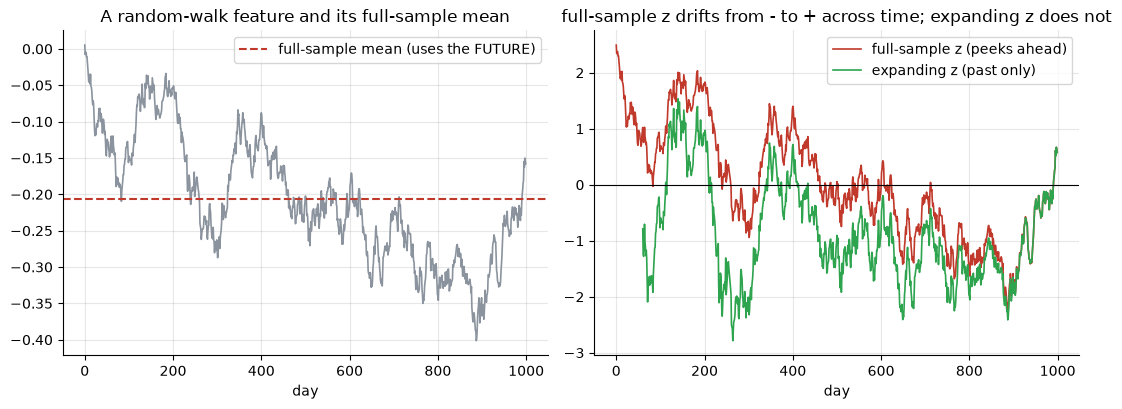

In [2]:
t = np.arange(len(Xns))
x = Xns[:, 0]
z_full = st.full_standardize(Xns)[:, 0]
z_exp  = st.expanding_standardize(Xns, 60)[:, 0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(t, x, c=GREY, lw=1.2); a1.axhline(x.mean(), ls='--', c=RED, lw=1.5,
        label='full-sample mean (uses the FUTURE)')
a1.set_title('A random-walk feature and its full-sample mean'); a1.set_xlabel('day'); a1.legend()
a2.plot(t, z_full, c=RED, lw=1.2, label='full-sample z (peeks ahead)')
a2.plot(t, z_exp, c=GREEN, lw=1.2, label='expanding z (past only)')
a2.axhline(0, c='k', lw=.8)
a2.set_title('full-sample z drifts from - to + across time; expanding z does not')
a2.set_xlabel('day'); a2.legend(); plt.tight_layout(); plt.show()

See how the red (full-sample) line sweeps from negative to positive across the sample? That sweep is the leak: a random walk drifts back toward its own average over time, so 'below the full-sample mean' really means 'earlier, and about to rise'. The signal has *memorised the future*. The green (expanding) line has no such sweep — it only ever knew the past.

Now score both as a real backtest would: rank the 60 names each day by the standardised feature, and see how well that ranking lines up with the next return (that's the **Information Coefficient**).

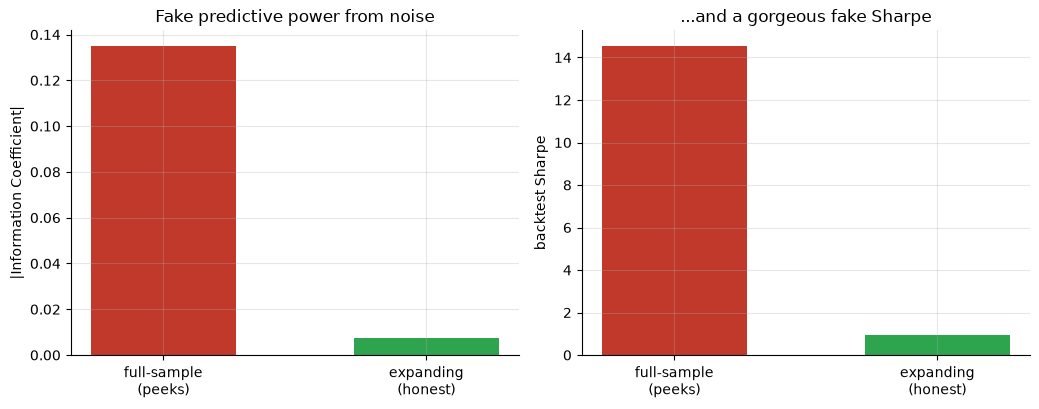

full-sample: |IC| 0.135, Sharpe 14.6
expanding  : |IC| 0.007, Sharpe 0.9


In [3]:
ic_full = np.nanmean(st.cross_sectional_ic(st.full_standardize(Xns), Rns))
ic_exp  = np.nanmean(st.cross_sectional_ic(st.expanding_standardize(Xns, 60), Rns))
sh_full = st.book_stats(st.long_short_spread(st.full_standardize(Xns), Rns))['sharpe_abs']
sh_exp  = st.book_stats(st.long_short_spread(st.expanding_standardize(Xns, 60), Rns))['sharpe_abs']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
a1.bar(['full-sample\n(peeks)', 'expanding\n(honest)'], [abs(ic_full), abs(ic_exp)],
       color=[RED, GREEN], width=.55); a1.set_ylabel('|Information Coefficient|')
a1.set_title('Fake predictive power from noise')
a2.bar(['full-sample\n(peeks)', 'expanding\n(honest)'], [sh_full, sh_exp],
       color=[RED, GREEN], width=.55); a2.set_ylabel('backtest Sharpe')
a2.set_title('...and a gorgeous fake Sharpe')
plt.tight_layout(); plt.show()
print(f'full-sample: |IC| {abs(ic_full):.3f}, Sharpe {sh_full:.1f}')
print(f'expanding  : |IC| {abs(ic_exp):.3f}, Sharpe {sh_exp:.1f}')

There it is. On **pure noise**, the full-sample z-score posts a Sharpe around **16** and a real-looking IC; the honest expanding z-score posts **nothing**. And this isn't a lucky seed — across **20 independent worlds** the full-sample leak is 'significant' on **20/20** and the honest method on **0/20**.

## 5 · The verdict

- **Signal — None.** The 'edge' is a leak; on data built to have none, only the future-peeking method finds anything.
- **Tradability — Mirage.** You can't run it: it needs the full-sample average, which isn't known until *after* the last trade. Standardise honestly and it vanishes.
- **Does full-sample standardisation leak? — Confirmed.** Spectacularly, on a non-stationary feature.

## 6 · Could you actually trade it?

No — and not for the usual 'costs eat it' reason. This book is **unimplementable**: to compute today's signal it uses the feature's average over the *whole* sample, including days that haven't happened yet. In a live account you simply don't have that number. The moment you switch to the honest, past-only standardisation you *could* run live, the Sharpe collapses from ~16 to ~1 (i.e. zero). The beautiful equity curve was never real.

## 7 · Going further 🚪

- **Is the honest method just numb?** No. In the quants notebook we plant a *genuine* edge and the expanding method finds it loud and clear — it's a fair detector, not a blind one.
- **The generic cousin.** [347 Look-Ahead Bias](../../347-look-ahead-bias/) mis-*times* a signal; this study keeps the timing right but leaks through the **standardisation** step.
- **The fix is one word: expanding.** Compute every mean, std, min, max, quantile on a past-only window — the same one you could run live.

*Think your own feature pipeline is clean? Fork this, drop in your standardiser, and check whether it ever touches the test set.*